<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


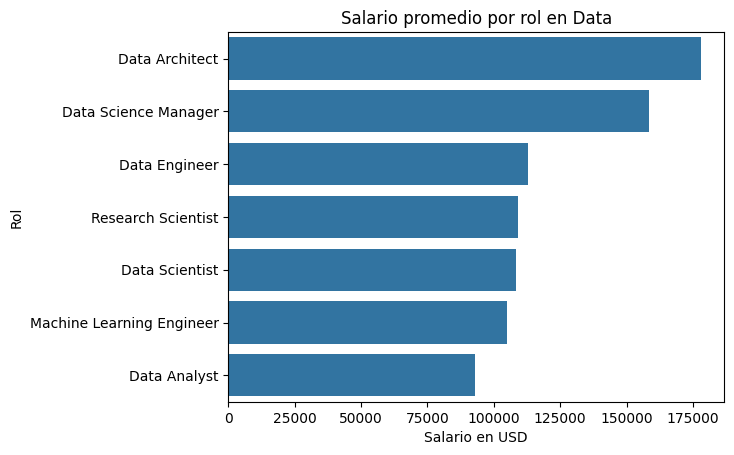

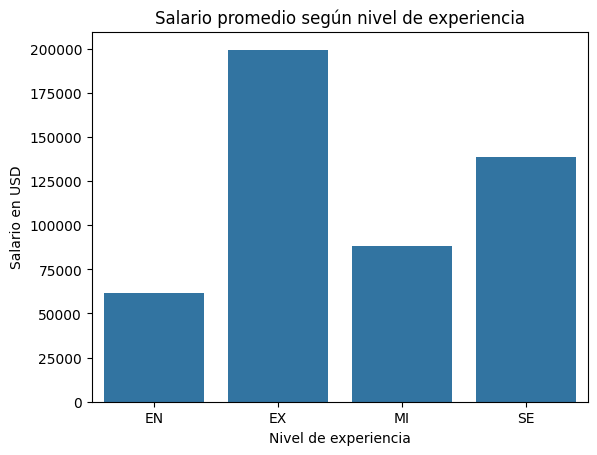

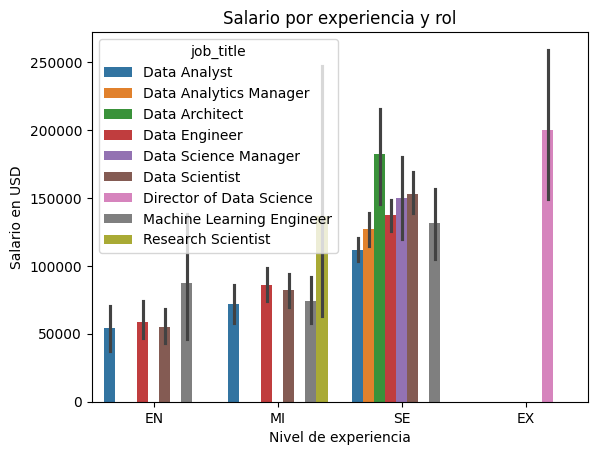

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Cargamos el dataset
df = pd.read_csv("data/raw/ds_salaries.csv")
# Exploración inicial
df.head()
df.info()
df.describe()
# Eliminamos columnas que no aportan valor al análisis
df = df.drop(columns=["Unnamed: 0", "salary", "salary_currency"])
# Analizamos salario promedio por rol
salary_by_role = df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False)
salary_by_role
# Filtramos roles con pocos registros para evitar resultados poco confiables
count_by_role = df["job_title"].value_counts()
valid_roles = count_by_role[count_by_role > 10].index
df_filtered = df[df["job_title"].isin(valid_roles)]
# Visualizamos salario promedio por rol
salary_plot = df_filtered.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).reset_index()
plt.figure()
sns.barplot(data=salary_plot, x="salary_in_usd", y="job_title")
plt.title("Salario promedio por rol en Data")
plt.xlabel("Salario en USD")
plt.ylabel("Rol")
plt.show()
# Analizamos salario según nivel de experiencia
exp_plot = df.groupby("experience_level")["salary_in_usd"].mean().reset_index()
plt.figure()
sns.barplot(data=exp_plot, x="experience_level", y="salary_in_usd")
plt.title("Salario promedio según nivel de experiencia")
plt.xlabel("Nivel de experiencia")
plt.ylabel("Salario en USD")
plt.show()
# Analizamos salario combinando rol y nivel de experiencia
count_combo = df.groupby(["job_title", "experience_level"]).size()
# Filtramos combinaciones con pocos datos para mejorar la confiabilidad
valid_combo = count_combo[count_combo > 5].index
df_combo_filtered = df.set_index(["job_title", "experience_level"]).loc[valid_combo].reset_index()
# Visualizamos salario por rol y experiencia
plt.figure()
sns.barplot(
    data=df_combo_filtered,
    x="experience_level",
    y="salary_in_usd",
    hue="job_title"
)
plt.title("Salario por experiencia y rol")
plt.xlabel("Nivel de experiencia")
plt.ylabel("Salario en USD")
plt.show()